In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import locale, matplotlib
locale.setlocale(locale.LC_ALL, 'ru_RU')
matplotlib.rcParams['axes.formatter.use_locale'] = True

from config import (
    N, p0, Lambda, lam, T, y_intervals,
    t_net_filtering, pi_uniform, pi_uniform, M_net,
    ht, delta, F, G, get_obs, exp_id, 
)
from SMJP import (
    sparse_mc, get_y_uniform, 
    #make_discretized_xi, make_discretized_eta
)
from utils import load_saved_path, save_path
from filter import Filter
from plots import plot_theta_background

print(exp_id)

example_for_arc3


In [2]:
load_path = False

In [3]:
if load_path:
    theta, y, t, theta_est, y_est, observations = load_saved_path(exp_id)
else:
    theta, y, t = sparse_mc(p0, Lambda, lam, T, get_y_uniform, y_intervals)
    observations = get_obs(t_net_filtering, theta, y, t)#.squeeze(axis=-1)

In [4]:
# fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')

# plot_freq = 1

# line, = ax.plot(
#     t_net_filtering[1::plot_freq],
#     observations[::plot_freq, 0],
#     lw=0.3,
#     color='navy',
#     label='$\\Delta \\xi$'
# )

# theta_states = plot_theta_background(
#     ax, theta, t, 
#     [f'$\\theta = e_{i}$' for i in range(1, N+1)], 
#     ['blue', 'green', 'red'], 
#     T, 
#     alpha=0.3
# )


# ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])

# ax.set_xticks(
#     ticks=list(range(0, 101, 20)), 
#     labels=['0', '20', '40', '60', '80', '$t$'],
#     fontsize=12,
# )

# ax.tick_params(labelsize=16)

# fig.legend(
#     handles=theta_states + [line],
#     loc='outside lower center',
#     ncols=len(theta_states) + 1,
#     fontsize=16,
#     frameon=False
# )

# plt.show()

In [5]:
theta_labels = ['$\\theta_t = e_1$', '$\\theta_t = e_2$',
                '$\\theta_t = e_3$', ]

theta_colors = ['green', 'chocolate', 'darkred',]

abc = ['а', 'б', 'в', 'г']

M = 1

def plot_obs(theta, y, t, dxi):

    fig, ax = plt.subplots(figsize=(16, 8), layout='constrained')

    ######   Y1   ######

    line1, = ax.plot(
        t_net_filtering[1:], 
        dxi / ht, 
        lw=0.6, 
        color='firebrick'
    )
    line2, = ax[0].step(
        np.concatenate([[0], t]),
        np.concatenate([[y[0, 0]], y[:, 0]]), 
        color='k'
    )
    
    lines = plot_theta_background(ax[0], theta, t, theta_labels, theta_colors, T)

    ax.set_xlabel(f'({abc[0]})', fontsize=14)
    ax.set_ylabel('$\\frac{\\boldsymbol{\\xi}^1_t}{\\Delta_t}$', fontsize=16, rotation='horizontal')

    ax.set_xticks(
        list(range(0, int(T) + 1, int(T) // 5)),
        [str(t) for t in  range(0, int(T), int(T) // 5)] + ['$t$']
    )
    ax.spines["bottom"].set_color("k")
    ax.spines["top"].set_color("k")
    ax.spines["left"].set_color("k")
    ax.spines["right"].set_color("k")
    ax.tick_params(labelsize=16)
    ax.set_xlim(0, T)
    ax.yaxis.set_label_coords(-0.075, 0.45)
        
    #ax[0].set_yticks([0.01, 0.03, 0.05, 0.07], ['0,01', '0,03', '0,05', '0,07'])
    #ax_2.set_yticks([0., 0.05, 0.1], ['0,00', '0,05', '0,10'])

    handles = lines + [ 
        line1, line2,
    ]

    labels = theta_labels + [
        '$\\boldsymbol{\\xi}_t / \\Delta_t$', 
        '$Y_t$'
    ]

    fig.legend(
        fontsize=16,
        handles=handles,
        labels=labels,
        loc='outside lower center',
        ncols=len(handles),
        #facecolor='gainsboro',
        frameon=False,
    )

    return fig, ax

In [7]:
if not load_path:
    filter = Filter(
        p0[:, np.newaxis] * pi_uniform, 
        pi_uniform, M_net, F, G,
        N, Lambda, ht, delta,
        n_points=1, two_jumps=False
    )

    est = filter.estimate()
    theta_est = [est[0]]
    y_est = [est[1]]

    for i, obs in enumerate(tqdm(observations), start=1):
        #obs = np.array([obs])
        filter.update(obs)
        est = filter.estimate()
        if np.any(np.isnan(est[0])) or np.any(np.isnan(est[1])):
            print(f'nan on {i}-th iter')
            break
        theta_est.append(est[0])
        y_est.append(est[1])
    
    theta_est = np.array(theta_est)
    y_est = np.array(y_est)

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [7]:
def plot_theta(theta, t, theta_opt, abc=abc):

    fig, ax = plt.subplots(N, figsize=((1 + np.sqrt(5))/2 * 8, 8), layout='constrained')

    for n in range(N):
        line1, = ax[n].step(
            [0] + list(t), 
            [(theta[0] == n)] + list(theta == n), 
            lw=1.5
        )

        line4, = ax[n].plot(t_net_filtering[:theta_opt.shape[0]], theta_opt[:, n],
                            color='red', lw=1)

        ax[n].set(
            xlim=(0, T),
            ylim=(-0.1, 1.1)
        )
        ax[n].set_xlabel('({})'.format(abc[n]), fontsize=13)
        ax[n].set_ylabel('$\\theta_t^{}$'.format(n+1), fontsize=14, rotation='horizontal')
        ax[n].yaxis.set_label_coords(-0.03, 0.4)
        ax[n].tick_params(labelsize=14)
        ax[n].set_xticks(
            [0, 20, 40, 60, 80, 100], 
            ['0', '20', '40', '60', '80', '$t$']
        )
        ax[n].set_yticks(ticks=[0, 1])
        ax[n].spines["bottom"].set_color("k")
        ax[n].spines["top"].set_color("k")
        ax[n].spines["left"].set_color("k")
        ax[n].spines["right"].set_color("k")

    fig.legend(
        fontsize=16,
        handles=[line1,
                    line4,
                    #line5
                ],
        labels=['$\\theta_t$',
                '$\\hat \\theta_t$',
                #'$\\tilde \\theta_t$'
                ],
        loc='outside lower center',
        ncol=4,
        framealpha=1,
        frameon=False
    )

    return fig, ax



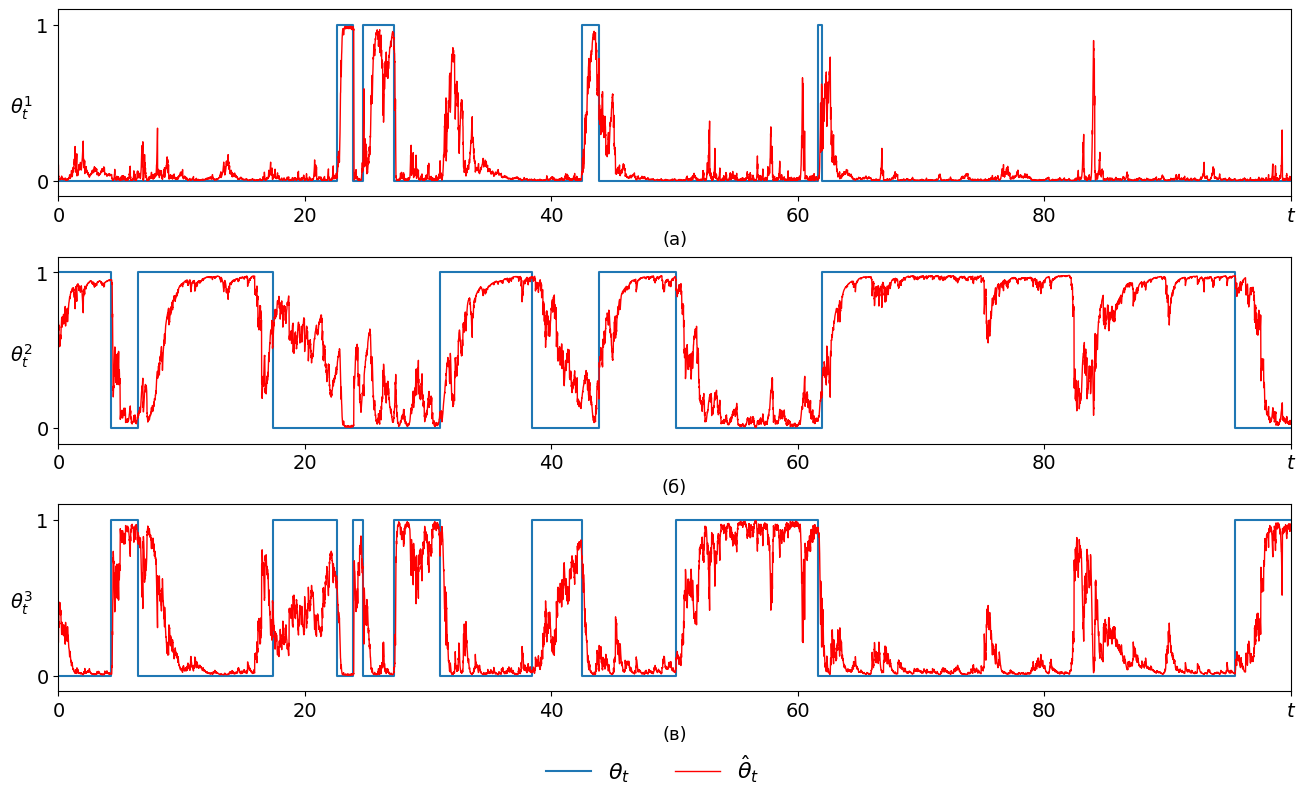

In [8]:
fig, ax = plot_theta(theta, t, theta_est)

plt.show()

In [9]:
def plot_y(
    theta, y, t, y_opt, 
    abc=abc, 
    theta_labels=theta_labels, 
    theta_colors=theta_colors
):
    fig, ax = plt.subplots(M, figsize=(16, 8), layout='constrained')

    labels = []

    line1, = ax[0].step( 
        [0] + list(t),
        [y[0, 0]] + list(y[:, 0]),
        where='pre', lw=2, color='k', 
    )
    line2, = ax[0].plot(
        t_net_filtering[:y_opt.shape[0]], y_opt[:, 0],
        color='red', lw=1.2
    )
    line3, = ax[1].step(
        [0] + list(t),
        [y[0, 1]] + list(y[:, 1]),
        where='pre', lw=2, color='navy',
    )
    line4, = ax[1].plot(
        t_net_filtering[:y_opt.shape[0]], y_opt[:, 1],
        color='green', lw=1.2,
    )

    for m in range(M):
        ax[m].set_ylabel('$Y^{}_t$'.format(m+1), fontsize=16, rotation='horizontal')
        ax[m].yaxis.set_label_coords(-0.05, 0.45)

        ax[m].set_xlim(0, T)
        ax[m].set_xlabel(f'({abc[m]})', fontsize=16)
        ax[m].set_xticks(
            [0, 20, 40, 60, 80, 100], 
            ['0', '20', '40', '60', '80', '$t$'],
        )
        ax[m].set_frame_on(True)
        ax[m].spines["bottom"].set_color("k")
        ax[m].spines["top"].set_color("k")
        ax[m].spines["left"].set_color("k")
        ax[m].spines["right"].set_color("k")
        ax[m].tick_params(labelsize=14)

        line1t, line2t, line3t, line4t = plot_theta_background(
            ax[m], theta, t, theta_labels, theta_colors, T, alpha=0.3
        )

    #ax[0].set_ylim(0.015, 0.065)
    #ax[0].set_yticks([0.02, 0.04, 0.06], ['0,02', '0,04', '0,06'])
    #ax[1].set_ylim(0.00, 0.11)
    #ax[1].set_yticks([0.01, 0.04, 0.07, 0.1], ['0,01', '0,04', '0,07', '0,10'])

    labels = theta_labels + ['$Y^1_t$', '$\\hat{Y}^1_t$', '$Y^2_t$', '$\\hat{Y}^2_t$']

    handles = [
        line1t, line2t, line3t, line4t, 
        line1, line2, line3, line4
    ]

    fig.legend(
        fontsize=18,
        handles=handles,
        labels=labels,
        loc='outside lower center',
        ncol=len(labels),
        frameon=False,
        #framealpha=1,
        #facecolor='gainsboro'
    )

    fig.align_ylabels()

    return fig, ax


In [10]:
if not load_path:
    save_path(exp_id, theta, y, t, theta_est, y_est, observations)

saved to saved_path_example_for_ia_7


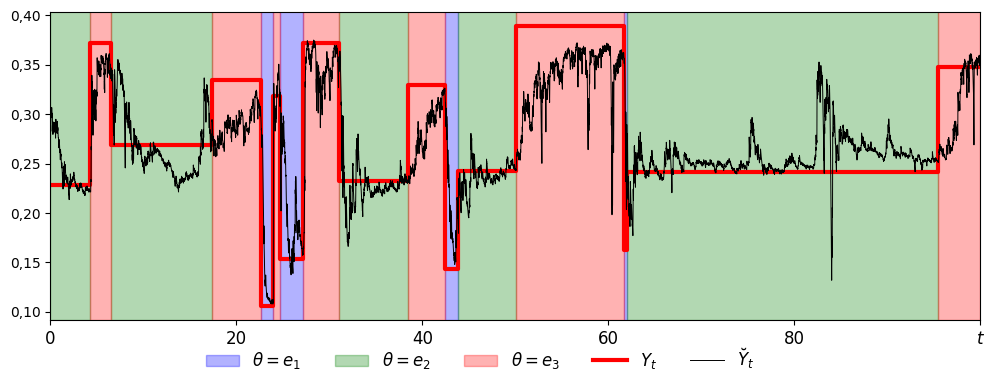

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
y_tmp = y[:, 0]
state, = ax.step(
    [0] + list(t),
    [y_tmp[0]] + list(y_tmp),
    where='pre', lw=3, color='red',
    label='$Y_t$'
)

theta_lines = plot_theta_background(
    ax, theta, t, 
    [f'$\\theta = e_{i}$' for i in range(1, N+1)], 
    ['blue', 'green', 'red'], 
    T, alpha=0.3
)

estimate, = ax.plot(t_net_filtering, y_est[:, 0], color='black', label='$\\breve{Y}_t$', lw=0.7)


#ax.axhline(y_intervals[0][0, 1])
#ax.axhline(y_intervals[0][1, 1])

ax.set_xlim(t_net_filtering[0], t_net_filtering[-1])
#ax.set_ylim(0.1, 0.5)

ax.set_xticks(
    ticks=list(range(0, 101, 20)), 
    labels=['0', '20', '40', '60', '80', '$t$'],
    fontsize=12,
)

# ax.set_yticks(
#     ticks=[0.1, 0.2, 0.3, 0.4, 0.5],
#     labels=[str(x) for x in [0.1, 0.2, 0.3, 0.4, 0.5]],
#     fontsize=12
# )

fig.legend(
    handles=theta_lines + [state, estimate],
    #labels=[f'$\\theta = e_{i}$' for i in range(1, N+1, 1)],
    ncols=5,
    fontsize=12,
    loc=(0.2, -0.005),
    frameon=False
)

plt.show()